In [86]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
import pandas as pd
import os
import zipfile
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image
import os
import torch

In [7]:
!ls
zip_path = "images.zip"
extract_dir = "images"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

images	images.zip  labels.csv	sample_data


In [21]:
i = 0
sizes = {}
for im_path in os.listdir("images/images/"):
  I = Image.open(f'images/images/{im_path}')
  I = np.array(I)
  sizes[im_path] = (I.shape[0], I.shape[1])

In [31]:
widest_img = max(sizes.items(), key=lambda x: x[1][1])
tallest_img = max(sizes.items(), key=lambda x:x[1][0])
filename, (h, w) = widest_img

print(f'Widest : {filename}: {h, w}')

filename, (h, w) = tallest_img
print(f'Tallest : {filename}: {h, w}')

Widest : B2024-06223 (1)_3.JPG: (200, 1403)
Tallest : B2024-01864 (1)_3.jpg: (200, 791)


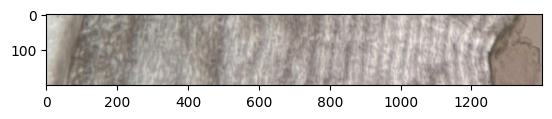

In [39]:
I = Image.open('images/images/B2024-06223 (1)_3.JPG')
I = np.array(I)[0:200, 0:1400]
plt.imshow(I)

In [33]:
widths = [size[1] for size in sizes.values()]
mean_width = np.mean(widths)
print(f"Mean width: {mean_width:.2f} pixels")

Mean width: 388.79 pixels


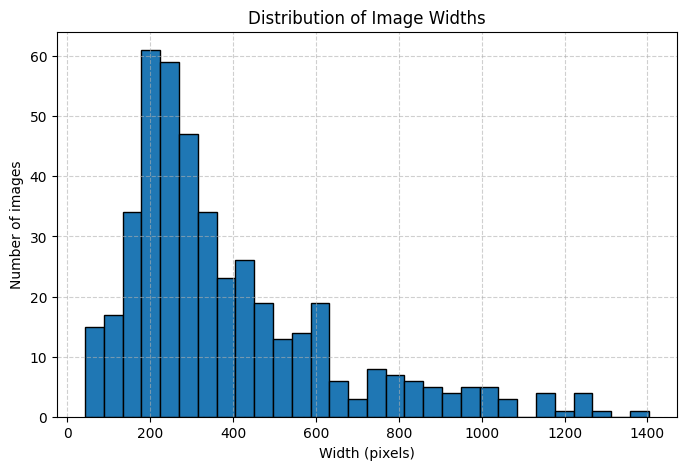

In [45]:
widths = [size[1] for size in sizes.values()]

plt.figure(figsize=(8, 5))
plt.hist(widths, bins=30, edgecolor='black')
plt.title("Distribution of Image Widths")
plt.xlabel("Width (pixels)")
plt.ylabel("Number of images")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Mean: tensor([0.4533, 0.4691, 0.4300]) Std: tensor([0.1011, 0.0967, 0.1070])

In [115]:
transform = transforms.Compose([
    transforms.Resize((200, 400)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4533, 0.4691, 0.4300],
        std=[0.1011, 0.0967, 0.1070]
    )
])

class SealToothDataset(Dataset):
    def __init__(self, root_dir, labels_dict, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.image_files = [f for f in os.listdir(root_dir)
                            if f in labels_dict and f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))]
        self.labels_dict = labels_dict

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        age = float(self.labels_dict[img_name])
        age = torch.tensor(age, dtype=torch.float32)
        return image, age

labels_df = pd.read_csv("labels.csv")
labels_dict = dict(zip(labels_df['image'], labels_df['age']))

In [118]:
dataset = SealToothDataset(root_dir="images/images/", labels_dict=labels_dict, transform=transform)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

images, ages = next(iter(loader))
print(images.shape)
print(ages)

torch.Size([8, 3, 200, 400])
tensor([ 1., 19.,  2.,  5.,  2.,  1.,  4.,  2.])


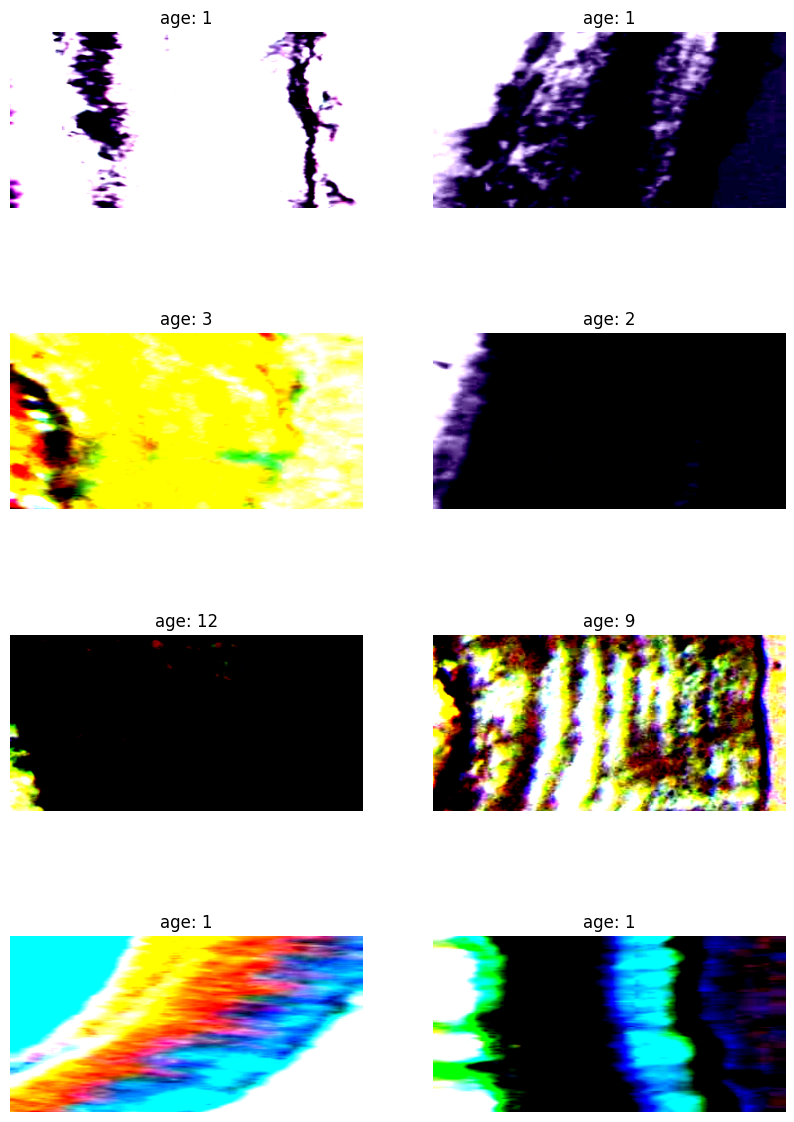

In [120]:
images, ages = next(iter(loader))
f, a = plt.subplots(4,2, figsize=(10, 15))
a = a.ravel()

for i in range(8):
    img = images[i].permute(1, 2, 0)
    a[i].imshow(img)
    a[i].set_title(f"age: {ages[i].item():.0f}")
    a[i].axis('off')